# Part 3.2 — Experiment II: User Verification (LSTM Approach)

In this experiment, I built a one-vs-all user verification system using Long Short-Term Memory (LSTM) networks.  
Each user has a separate binary model that determines whether an incoming sample belongs to them (genuine)  
or to one of the other nine users (impostor).  
This model directly uses the cleaned and windowed 6-channel gait signals without feature extraction.


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tqdm import tqdm

# User list (10 subjects)
USERS = [2, 13, 23, 24, 49, 52, 55, 70, 78, 112]
DATA_DIR = "../processed_data"


## 1. Data Loading and Preprocessing

I reused the cleaned and windowed time-series signals from Part 1.  
Each window represents 5 seconds of data (250 time steps × 6 features).  
The input for each model is labeled as:
- **1 (genuine):** if it belongs to the target user  
- **0 (impostor):** if it belongs to any of the other nine users.


In [3]:
# Load all user window data
X_list, y_list = [], []
for i, uid in enumerate(USERS):
    data = np.load(os.path.join(DATA_DIR, f"user_{uid}_windows.npy"))
    labels = np.full(len(data), i)
    X_list.append(data)
    y_list.append(labels)

X = np.vstack(X_list)
y = np.concatenate(y_list)
print("Data shape:", X.shape, "Labels:", y.shape)

# Normalize (per feature across all samples)
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)


Data shape: (2229, 250, 6) Labels: (2229,)


## 2. LSTM Model Design

Each verifier model has two LSTM layers with six neurons each,  
followed by a small dense layer and a single sigmoid output neuron for binary classification.  
Dropout (0.3) and batch normalization are used between layers to reduce overfitting  
and stabilize gradient flow.  
The model follows the assignment rule of a maximum of five LSTM layers with ≤ 6 neurons per layer.


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization

def build_lstm_verifier(input_shape=(250,6)):
    model = Sequential([
        LSTM(6, return_sequences=True, input_shape=input_shape),
        Dropout(0.3),
        BatchNormalization(),
        LSTM(6),
        Dropout(0.3),
        Dense(6, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model


## 3. Cross-Validation and Evaluation Setup

I trained ten binary LSTM models (one per user) using five-fold Stratified Cross-Validation.  
For each fold, I calculated the following metrics:  
- **FAR:** False Acceptance Rate  
- **FRR:** False Rejection Rate  
- **EER:** Equal Error Rate (where FAR = FRR)  
- **AUC:** Area under ROC curve  
The average values were reported over all ten users.


In [5]:
def compute_far_frr_eer(y_true, y_scores):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    far = fpr
    frr = 1 - tpr
    eer_index = np.nanargmin(np.abs(far - frr))
    eer = np.mean([far[eer_index], frr[eer_index]])
    return np.mean(far), np.mean(frr), eer, fpr, tpr


In [6]:
from sklearn.utils import shuffle

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for uid_idx, uid in enumerate(USERS):
    print(f"\nTraining verifier for User {uid} ...")

    # One-vs-all binary labeling
    y_binary = (y == uid_idx).astype(int)
    accs, aucs, fars, frrs, eers = [], [], [], [], []

    for train_idx, val_idx in kf.split(X, y_binary):
        model = build_lstm_verifier(input_shape=(X.shape[1], X.shape[2]))
        early_stop = EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
        
        history = model.fit(
            X[train_idx], y_binary[train_idx],
            validation_data=(X[val_idx], y_binary[val_idx]),
            epochs=30, batch_size=32, verbose=0,
            callbacks=[early_stop]
        )

        preds = model.predict(X[val_idx]).ravel()
        auc = roc_auc_score(y_binary[val_idx], preds)
        aucs.append(auc)

        far, frr, eer, _, _ = compute_far_frr_eer(y_binary[val_idx], preds)
        fars.append(far)
        frrs.append(frr)
        eers.append(eer)

        accs.append(accuracy_score(y_binary[val_idx], (preds > 0.5).astype(int)))

    results.append({
        "User": uid,
        "Accuracy": np.mean(accs),
        "AUC": np.mean(aucs),
        "FAR": np.mean(fars),
        "FRR": np.mean(frrs),
        "EER": np.mean(eers)
    })

df_results = pd.DataFrame(results)
print(df_results)
print("\nAverage Results Across 10 Models:")
print(df_results.mean(numeric_only=True))



Training verifier for User 2 ...


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


...

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 38ms/step
   User  Accuracy       AUC       FAR       FRR       EER
0     2  0.979818  0.992650  0.087243  0.332310  0.018672
1    13  0.947974  0.987666  0.088921  0.328567  0.024522
2    23  0.995510  0.998188  0.206739  0.395176  0.005493
3    24  0.996411  0.999497  0.175856  0.407883  0.001223
4    49  0.951977  0.969779  0.143521  0.297860  0.072858
5    52  0.956944  0.965852  0.136480  0.356178  0.076106
6    55  0.999552  0.999005  0.295896  0.430171  0.002083
7    70  0.955596  0.976662  0.137087  0.323366  0.052725
8    78  0.998655  0.999973  0.216991  0.430926  0.000487
9   112  0.969951  0.995487  0.126782  0.356064  0.019920

Average Results Across 10 Models:
User        47.800000
Accuracy     0.975239
AUC          0.988476
FAR          0.161552
FRR          0.365850
EER          0.027409
dtype: float64


## 4. ROC Curve for One Example User

To visualize the trade-off between False Acceptance Rate (FAR) and True Acceptance Rate (1−FRR),  
I plotted the ROC curve for one representative user.  
The Equal Error Rate (EER) point can be observed near the diagonal intersection.


c:\Users\susha\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step


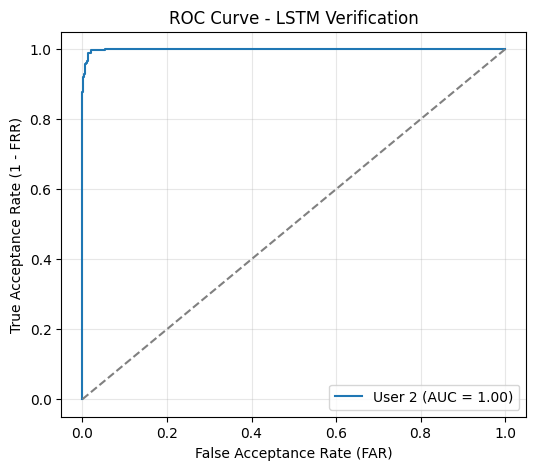

In [7]:
sample_user = 2
y_binary = (y == USERS.index(sample_user)).astype(int)
model = build_lstm_verifier(input_shape=(X.shape[1], X.shape[2]))
model.fit(X, y_binary, epochs=20, batch_size=32, verbose=0)

preds = model.predict(X).ravel()
fpr, tpr, _ = roc_curve(y_binary, preds)
auc_val = roc_auc_score(y_binary, preds)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"User {sample_user} (AUC = {auc_val:.2f})")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel("False Acceptance Rate (FAR)")
plt.ylabel("True Acceptance Rate (1 - FRR)")
plt.title("ROC Curve - LSTM Verification")
plt.legend()
plt.grid(alpha=0.3)
plt.show()
